# Pembuatan Model Rekomendasi Vegetasi Berbasis Zona

Notebook ini berisi proses pembuatan model klasifikasi tanaman berbasis zona, mulai dari pemuatan dataset, eksplorasi data, rekayasa fitur, pemilihan model, evaluasi, hingga penyimpanan artifact.


## 1. Setup Environment


In [1]:
import os
import sys
from pathlib import Path


def _is_project_root(path: Path) -> bool:
    return (path / "scripts").exists() and (path / "data").exists() and (path / "artifacts").exists()


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if _is_project_root(candidate):
            return candidate
    raise FileNotFoundError("Project root tidak ditemukan.")


PROJECT_ROOT = resolve_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = /home/stardust/Documents/Kuliah/DATAHACTHON


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

from scripts.prepare_zone_dataset_expanded import main as prepare_zone_dataset_expanded
from scripts.train_zone_model_expanded import main as train_zone_model_expanded


## 2. Konfigurasi Pipeline

Gunakan `REBUILD_DATASET=True` untuk membangun ulang dataset zona expanded. Gunakan `FIT_MODEL=True` untuk melatih ulang model dan menulis ulang artifact evaluasi.


In [3]:
REBUILD_DATASET = False
FIT_MODEL = False
RANDOM_STATE = 42

DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "zone_dataset_expanded_id.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "zone_dataset_expanded_id_metadata.json"
METRICS_PATH = PROJECT_ROOT / "artifacts" / "best_model_metrics_expanded.json"
COMPARISON_PATH = PROJECT_ROOT / "artifacts" / "model_comparison_expanded.csv"
REPORT_PATH = PROJECT_ROOT / "artifacts" / "classification_report_best_model_expanded.txt"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "best_zone_model_expanded.joblib"
PIPELINE_PATH = PROJECT_ROOT / "artifacts" / "pipelines" / "best_zone_pipeline_expanded.joblib"


## 3. Persiapan Dataset Zona


In [4]:
if REBUILD_DATASET:
    prepare_zone_dataset_expanded()

zone_df = pd.read_csv(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

print("Dataset shape:", zone_df.shape)
print("Jumlah kelas:", zone_df["zone_target"].nunique())
display(zone_df.head())


Dataset shape: (77, 66)
Jumlah kelas: 13


,zone_id,base_context_id,source_dataset,source_region,integration_strategy,sample_count,context_sample_count,context_cluster_count,sample_count_risk_flag,label_nunique,zone_label_dominance_ratio,ph_mean,ph_std,ph_min,ph_max,ph_median,ph_count,ph_range,ph_cv,ph_missing_ratio,nitrogen_mean,nitrogen_std,nitrogen_min,nitrogen_max,nitrogen_median,nitrogen_count,nitrogen_range,nitrogen_cv,nitrogen_missing_ratio,phosphorus_mean,phosphorus_std,phosphorus_min,phosphorus_max,phosphorus_median,phosphorus_count,phosphorus_range,phosphorus_cv,phosphorus_missing_ratio,potassium_mean,potassium_std,potassium_min,potassium_max,potassium_median,potassium_count,potassium_range,potassium_cv,potassium_missing_ratio,temperature_mean_mean,temperature_mean_std,temperature_mean_min,temperature_mean_max,temperature_mean_median,temperature_mean_count,temperature_mean_range,temperature_mean_cv,temperature_mean_missing_ratio,rainfall_mean_mean,rainfall_mean_std,rainfall_mean_min,rainfall_mean_max,rainfall_mean_median,rainfall_mean_count,rainfall_mean_range,rainfall_mean_cv,rainfall_mean_missing_ratio,zone_target
0,active::zone_01_02,active::1,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,20,236,9,ok,3,0.700000,6.762667,0.306931,6.40,7.37,6.700,15,0.97,0.045386,0.0,0.191767,0.035838,0.1417,0.2518,0.19470,15,0.1101,0.186882,0.0,8.579000,9.290769,2.000,34.000,6.000,15,32.000,1.082966,0.0,385.592800,99.199484,208.600,537.000,387.000,15,328.400,0.257265,0.0,13.937083,0.0,13.937083,13.937083,13.937083,15,0.0,0.0,0.0,3.288333,0.0,3.288333,3.288333,3.288333,15,0.0,0.0,0.0,Gandum
1,active::zone_01_03,active::1,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,58,236,9,ok,3,0.603448,5.715769,0.204262,5.28,6.35,5.705,52,1.07,0.035737,0.0,0.246537,0.025635,0.1679,0.2992,0.25180,52,0.1313,0.103980,0.0,13.815135,15.138170,4.267,85.046,8.804,52,80.779,1.095767,0.0,223.305635,93.837547,55.537,507.187,205.185,52,451.650,0.420220,0.0,13.937083,0.0,13.937083,13.937083,13.937083,52,0.0,0.0,0.0,3.288333,0.0,3.288333,3.288333,3.288333,52,0.0,0.0,0.0,Jelai
2,active::zone_01_08,active::1,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,21,236,9,ok,2,0.952381,5.854286,0.261698,5.50,6.40,5.800,21,0.90,0.044702,0.0,0.343938,0.041740,0.2860,0.4366,0.34110,21,0.1506,0.121360,0.0,10.156190,8.193431,3.000,34.000,7.000,21,31.000,0.806743,0.0,259.322333,111.921925,60.769,445.000,258.000,21,384.231,0.431594,0.0,13.937083,0.0,13.937083,13.937083,13.937083,21,0.0,0.0,0.0,3.288333,0.0,3.288333,3.288333,3.288333,21,0.0,0.0,0.0,Jelai
3,active::zone_02_05,active::2,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,59,286,11,ok,6,0.711864,5.248772,0.278459,4.30,5.91,5.200,57,1.61,0.053052,0.0,0.168420,0.026202,0.1094,0.2289,0.16230,57,0.1195,0.155578,0.0,4.776140,2.527142,1.000,12.000,4.000,57,11.000,0.529118,0.0,296.384386,98.488825,85.000,501.000,288.000,57,416.000,0.332301,0.0,17.892500,0.0,17.892500,17.892500,17.892500,57,0.0,0.0,0.0,4.475833,0.0,4.475833,4.475833,4.475833,57,0.0,0.0,0.0,Teff
4,active::zone_06_11,active::6,mendeley_8v757rr4st_crop_recommendation_soil_w...,Ethiopia,native_zone_dataset,24,457,18,ok,5,0.708333,6.600455,0.475840,5.80,7.30,6.650,22,1.50,0.072092,0.0,0.155805,0.034447,0.0742,0.2118,0.15185,22,0.1376,0.221089,0.0,68.168182,44.467038,4.000,138.000,77.000,22,134.000,0.652314,0.0,664.590909,137.121656,407.000,933.000,632.500,22,526.000,0.206325,0.0,16.695000,0.0,16.695000,16.695000,16.695000,22,0.0,0.0,0.0,5.371667,0.0,5.371667,5.371667,5.371667,22,0.0,0.0,0.0,Teff


In [5]:
dataset_summary = pd.DataFrame(
    [
        {"item": "jumlah_zona", "value": zone_df.shape[0]},
        {"item": "jumlah_kolom", "value": zone_df.shape[1]},
        {"item": "jumlah_kelas", "value": zone_df["zone_target"].nunique()},
        {"item": "jumlah_context_group", "value": zone_df["base_context_id"].nunique()},
        {"item": "target_column", "value": "zone_target"},
    ]
)
display(dataset_summary)

display(pd.Series(metadata.get("source_distribution", {}), name="zone_count").rename_axis("source_dataset").reset_index())


,item,value
0,jumlah_zona,77
1,jumlah_kolom,66
2,jumlah_kelas,13
3,jumlah_context_group,53
4,target_column,zone_target


,source_dataset,zone_count
0,crop_recommendation_kaggle_mirror,44
1,mendeley_8v757rr4st_crop_recommendation_soil_w...,33


## 4. Exploratory Data Analysis


,zone_target,zone_count
0,Jagung,17
1,Teff,12
2,Padi,6
3,Pisang,6
4,Kelapa,5
5,Mangga,5
6,Gandum,4
7,Jelai,4
8,Jeruk,4
9,Semangka,4


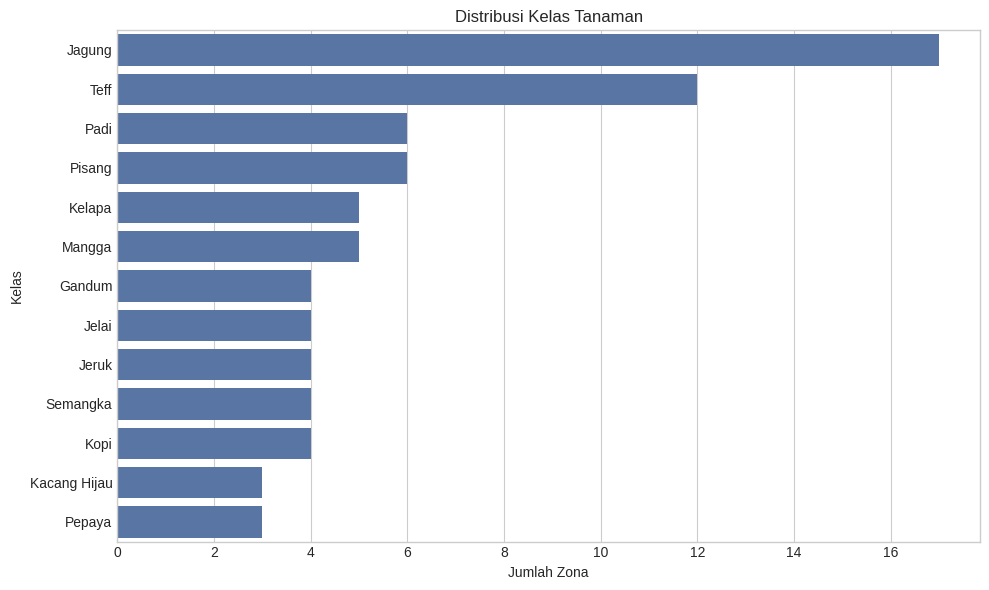

In [6]:
target_counts = zone_df["zone_target"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=target_counts.values, y=target_counts.index)
plt.title("Distribusi Kelas Tanaman")
plt.xlabel("Jumlah Zona")
plt.ylabel("Kelas")
plt.tight_layout()

display(target_counts.rename_axis("zone_target").reset_index(name="zone_count"))


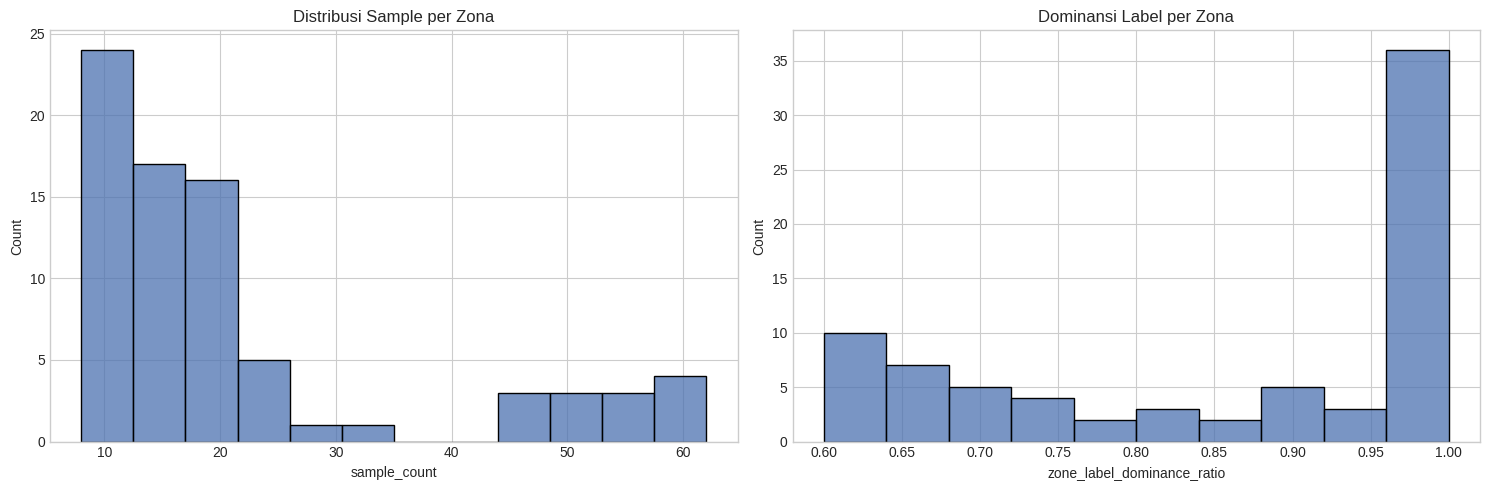

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(zone_df["sample_count"], bins=12, ax=axes[0])
axes[0].set_title("Distribusi Sample per Zona")
axes[0].set_xlabel("sample_count")

if "zone_label_dominance_ratio" in zone_df.columns:
    sns.histplot(zone_df["zone_label_dominance_ratio"], bins=10, ax=axes[1])
    axes[1].set_title("Dominansi Label per Zona")
    axes[1].set_xlabel("zone_label_dominance_ratio")
else:
    axes[1].axis("off")

plt.tight_layout()


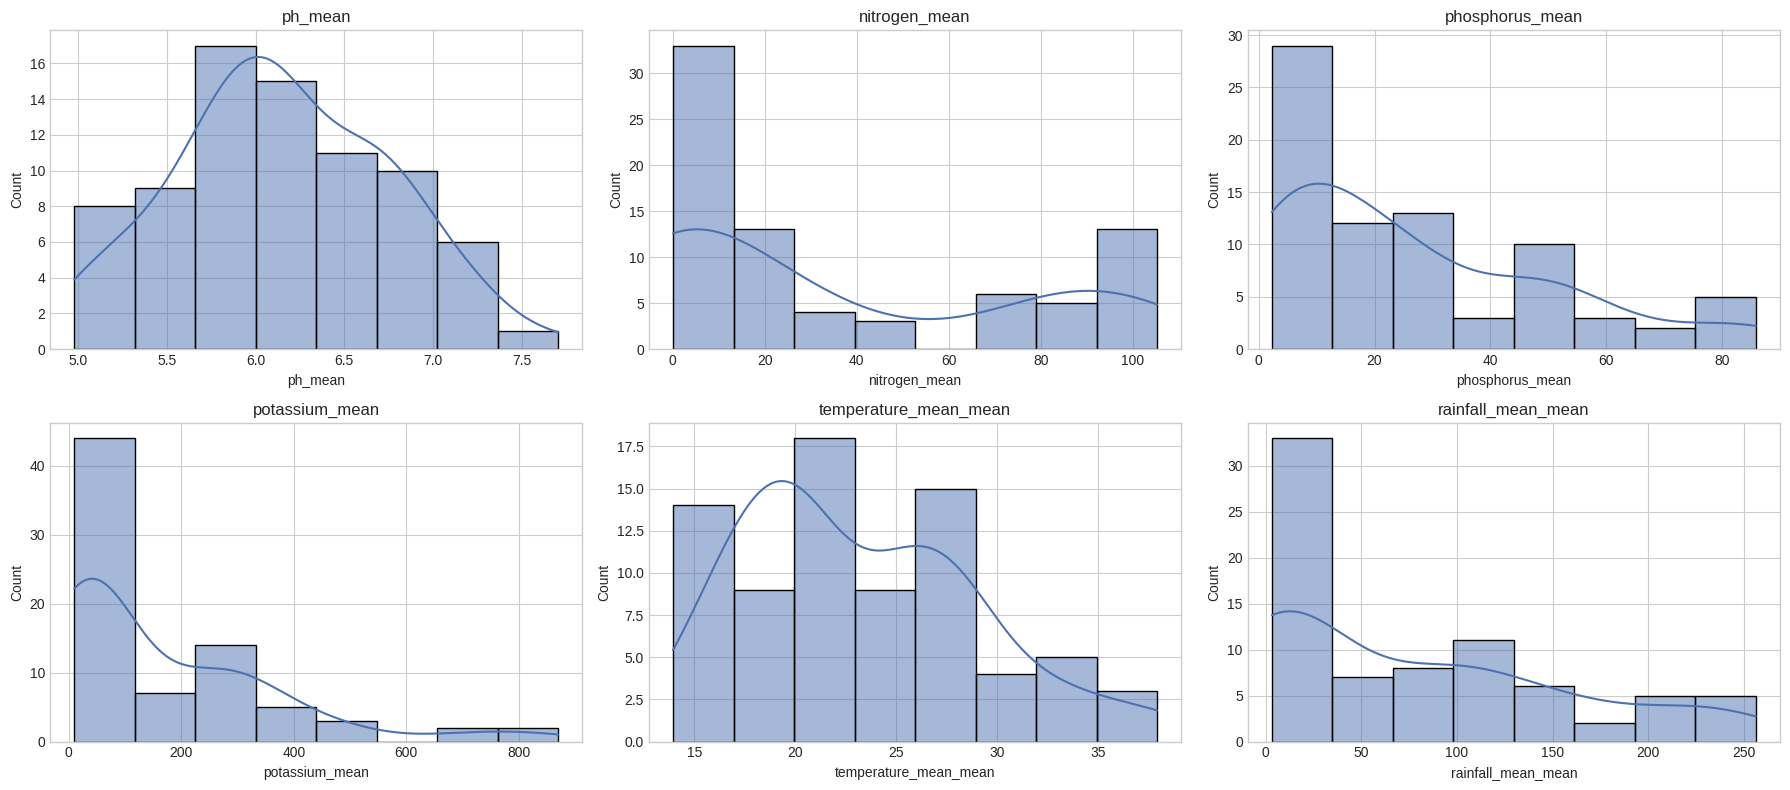

In [8]:
core_features = [
    "ph_mean",
    "nitrogen_mean",
    "phosphorus_mean",
    "potassium_mean",
    "temperature_mean_mean",
    "rainfall_mean_mean",
]
core_features = [column for column in core_features if column in zone_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for ax, column in zip(axes, core_features):
    sns.histplot(zone_df[column], kde=True, ax=ax)
    ax.set_title(column)
for ax in axes[len(core_features):]:
    ax.axis("off")
plt.tight_layout()


In [9]:
missing_summary = (
    zone_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_ratio")
    .reset_index()
    .rename(columns={"index": "column"})
)
display(missing_summary.head(20))


,column,missing_ratio
0,zone_id,0.0
1,base_context_id,0.0
2,source_dataset,0.0
3,source_region,0.0
4,integration_strategy,0.0
5,sample_count,0.0
6,context_sample_count,0.0
7,context_cluster_count,0.0
8,sample_count_risk_flag,0.0
9,label_nunique,0.0


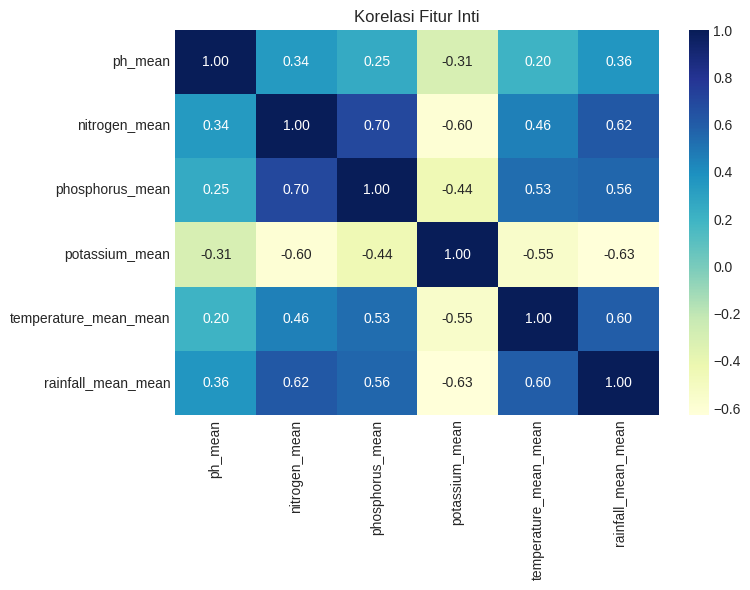

In [10]:
corr_matrix = zone_df[core_features].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Korelasi Fitur Inti")
plt.tight_layout()


## 5. Rekayasa Fitur Zona

Dataset model menggunakan dua skenario fitur:

- `zone_mean_only`: fitur rata-rata zona
- `zone_mean_plus_variability`: fitur rata-rata ditambah variasi internal zona seperti `std`, `min`, `max`, `median`, `range`, `cv`, dan `missing_ratio`


In [11]:
metrics_payload = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

scenario_summary = pd.DataFrame(
    [
        {
            "scenario": "zone_mean_only",
            "feature_count": len(metrics_payload["zone_mean_only"]["feature_columns"]),
        },
        {
            "scenario": "zone_mean_plus_variability",
            "feature_count": len(metrics_payload["zone_mean_plus_variability"]["feature_columns"]),
        },
    ]
)
display(scenario_summary)


,scenario,feature_count
0,zone_mean_only,9
1,zone_mean_plus_variability,57


## 6. Training dan Model Selection

Pipeline training membandingkan beberapa model tabular dan memilih model berdasarkan `macro F1` pada group-aware cross validation.


In [12]:
if FIT_MODEL:
    metrics_payload = train_zone_model_expanded()

comparison_df = pd.read_csv(COMPARISON_PATH)
display(
    comparison_df.sort_values(
        ["scenario_name", "cv_f1_macro_mean", "test_f1_macro"],
        ascending=[True, False, False],
    ).reset_index(drop=True)
)


,scenario_name,model_name,fit_status,selection_strategy,cv_splits,cv_accuracy_mean,cv_precision_macro_mean,cv_recall_macro_mean,cv_f1_macro_mean,cv_f1_weighted_mean,cv_accuracy_std,cv_f1_macro_std,selected_for_tuning,is_scenario_winner,is_final_selected,tuned_cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_params_json,error_message
0,zone_mean_only,extra_trees,success,stratified_group_kfold,2,0.716524,0.744017,0.780983,0.732338,0.695187,0.024217,0.023791,True,True,False,0.732338,0.916667,0.884615,0.884615,0.884615,0.916667,"{""model__n_estimators"": 360, ""model__min_sampl...",NaN
1,zone_mean_only,logistic_regression,success,stratified_group_kfold,2,0.623932,0.747436,0.733974,0.724176,0.632112,0.068376,0.001099,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,zone_mean_only,catboost,success,stratified_group_kfold,2,0.510684,0.610989,0.673077,0.607942,0.469133,0.066239,0.031252,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,zone_mean_only,lightgbm,success,stratified_group_kfold,2,0.605413,0.624237,0.632479,0.602875,0.596357,0.086895,0.053535,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,zone_mean_only,random_forest,success,stratified_group_kfold,2,0.564103,0.499359,0.569444,0.492054,0.509862,0.102564,0.081664,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,zone_mean_only,xgboost,success,stratified_group_kfold,2,0.525641,0.383089,0.477564,0.399263,0.456647,0.141026,0.166803,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,zone_mean_plus_variability,extra_trees,success,stratified_group_kfold,2,0.772792,0.816667,0.829060,0.805739,0.758866,0.042023,0.066056,True,True,True,0.805739,0.875000,0.820513,0.846154,0.830769,0.841667,"{""model__n_estimators"": 360, ""model__min_sampl...",NaN
7,zone_mean_plus_variability,logistic_regression,success,stratified_group_kfold,2,0.735755,0.775000,0.785256,0.768602,0.731607,0.004986,0.016466,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,zone_mean_plus_variability,catboost,success,stratified_group_kfold,2,0.622507,0.729167,0.733974,0.687821,0.617901,0.007123,0.030128,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,zone_mean_plus_variability,random_forest,success,stratified_group_kfold,2,0.640313,0.657234,0.679487,0.635780,0.599008,0.063390,0.084132,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
selected_scenario = metrics_payload["selected_zone_scenario"]
selected_model = metrics_payload["selected_zone_model_name"]
selected_metrics = metrics_payload["selected_zone_test_metrics"]

selected_summary = pd.DataFrame(
    [
        {"item": "selected_scenario", "value": selected_scenario},
        {"item": "selected_model", "value": selected_model},
        {"item": "cv_macro_f1", "value": metrics_payload["selected_zone_cv_metric_value"]},
        {"item": "test_accuracy", "value": selected_metrics["accuracy"]},
        {"item": "test_macro_precision", "value": selected_metrics["precision_macro"]},
        {"item": "test_macro_recall", "value": selected_metrics["recall_macro"]},
        {"item": "test_macro_f1", "value": selected_metrics["f1_macro"]},
        {"item": "test_weighted_f1", "value": selected_metrics["f1_weighted"]},
    ]
)
display(selected_summary)


,item,value
0,selected_scenario,zone_mean_plus_variability
1,selected_model,extra_trees
2,cv_macro_f1,0.805739
3,test_accuracy,0.875
4,test_macro_precision,0.820513
5,test_macro_recall,0.846154
6,test_macro_f1,0.830769
7,test_weighted_f1,0.841667


## 7. Evaluasi Model Final


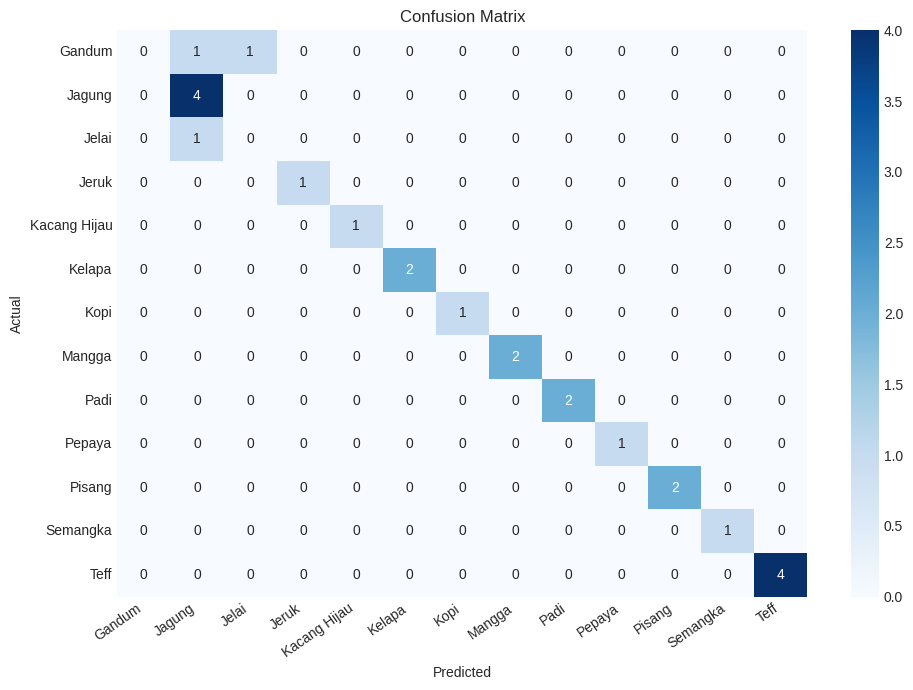

In [14]:
labels = metrics_payload["selected_zone_confusion_matrix_labels"]
matrix = np.asarray(metrics_payload["selected_zone_confusion_matrix"])

plt.figure(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()


In [15]:
report = metrics_payload["selected_zone_classification_report"]
per_class_rows = []
for label, values in report.items():
    if isinstance(values, dict) and label not in {"macro avg", "weighted avg"}:
        per_class_rows.append(
            {
                "label": label,
                "precision": values["precision"],
                "recall": values["recall"],
                "f1_score": values["f1-score"],
                "support": values["support"],
            }
        )

per_class_df = pd.DataFrame(per_class_rows).sort_values(["support", "f1_score"], ascending=[True, False])
display(per_class_df)


,label,precision,recall,f1_score,support
3,Jeruk,1.000000,1.0,1.0,1.0
4,Kacang Hijau,1.000000,1.0,1.0,1.0
6,Kopi,1.000000,1.0,1.0,1.0
9,Pepaya,1.000000,1.0,1.0,1.0
11,Semangka,1.000000,1.0,1.0,1.0
2,Jelai,0.000000,0.0,0.0,1.0
5,Kelapa,1.000000,1.0,1.0,2.0
7,Mangga,1.000000,1.0,1.0,2.0
8,Padi,1.000000,1.0,1.0,2.0
10,Pisang,1.000000,1.0,1.0,2.0


In [16]:
print(REPORT_PATH.read_text(encoding="utf-8"))


              precision    recall  f1-score   support

      Gandum       0.00      0.00      0.00         2
      Jagung       0.67      1.00      0.80         4
       Jelai       0.00      0.00      0.00         1
       Jeruk       1.00      1.00      1.00         1
Kacang Hijau       1.00      1.00      1.00         1
      Kelapa       1.00      1.00      1.00         2
        Kopi       1.00      1.00      1.00         1
      Mangga       1.00      1.00      1.00         2
        Padi       1.00      1.00      1.00         2
      Pepaya       1.00      1.00      1.00         1
      Pisang       1.00      1.00      1.00         2
    Semangka       1.00      1.00      1.00         1
        Teff       1.00      1.00      1.00         4

    accuracy                           0.88        24
   macro avg       0.82      0.85      0.83        24
weighted avg       0.82      0.88      0.84        24



## 8. Penyimpanan Artifact


In [17]:
artifact_summary = pd.DataFrame(
    [
        {"artifact": "model", "path": str(MODEL_PATH.relative_to(PROJECT_ROOT)), "exists": MODEL_PATH.exists()},
        {"artifact": "pipeline", "path": str(PIPELINE_PATH.relative_to(PROJECT_ROOT)), "exists": PIPELINE_PATH.exists()},
        {"artifact": "metrics", "path": str(METRICS_PATH.relative_to(PROJECT_ROOT)), "exists": METRICS_PATH.exists()},
        {"artifact": "comparison", "path": str(COMPARISON_PATH.relative_to(PROJECT_ROOT)), "exists": COMPARISON_PATH.exists()},
        {"artifact": "classification_report", "path": str(REPORT_PATH.relative_to(PROJECT_ROOT)), "exists": REPORT_PATH.exists()},
    ]
)
display(artifact_summary)


,artifact,path,exists
0,model,artifacts/models/best_zone_model_expanded.joblib,True
1,pipeline,artifacts/pipelines/best_zone_pipeline_expande...,True
2,metrics,artifacts/best_model_metrics_expanded.json,True
3,comparison,artifacts/model_comparison_expanded.csv,True
4,classification_report,artifacts/classification_report_best_model_exp...,True
